# 📡 Telco Customer Churn — Exploratory Data Analysis

**Dataset:** Telco Customer Churn (7,043 customers · 21 features)  
**Goal:** Understand what drives customer churn and identify high-risk customer profiles.

---
### Sections
1. Setup & Data Loading  
2. Data Overview & Quality Check  
3. Churn Overview  
4. Contract, Tenure & Payment Analysis  
5. Service Usage Analysis  
6. Demographics Analysis  
7. Revenue at Risk  
8. Key Takeaways


## 1. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
CHURN_COLORS = {0: '#2ECC71', 1: '#E74C3C'}   # green = retained, red = churned

In [6]:
df = pd.read_csv('Telco Customer.csv')

# Fix TotalCharges — blank strings for new customers (tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Binary churn column for arithmetic
df['Churned'] = (df['Churn'] == 'Yes').astype(int)

# Tenure bands
bins   = [0, 6, 12, 24, 48, df['tenure'].max() + 1]
labels = ['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49+ mo']
df['Tenure Band'] = pd.cut(df['tenure'], bins=bins, labels=labels,
                            right=True, include_lowest=True)

# Service count per customer
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df['Service Count'] = df[service_cols].apply(
    lambda col: col.map(lambda v: 1 if v == 'Yes' else 0)
).sum(axis=1)

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churned,Tenure Band,Service Count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-6 mo,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 mo,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-6 mo,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 mo,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-6 mo,0


## 2. Data Overview & Quality Check

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [8]:
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Service Count']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,Service Count
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.04
std,24.56,30.09,2266.79,1.85
min,0.00,18.25,0.00,0.00
25%,9.00,35.50,398.55,0.00
50%,29.00,70.35,1394.55,2.00
75%,55.00,89.85,3786.60,3.00
max,72.00,118.75,8684.80,6.00


In [9]:
# Missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.any() else "None ✓")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Unique customers: {df['customerID'].nunique():,}")

Missing values:
None ✓

Duplicate rows: 0
Unique customers: 7,043


In [10]:
# Value counts for key categorical columns
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522


## 3. Churn Overview

In [11]:
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churned'].mean() * 100

print(f"Total customers  : {len(df):,}")
print(f"Churned          : {churn_counts['Yes']:,}  ({churn_rate:.1f}%)")
print(f"Retained         : {churn_counts['No']:,}  ({100 - churn_rate:.1f}%)")

Total customers  : 7,043
Churned          : 1,869  (26.5%)
Retained         : 5,174  (73.5%)


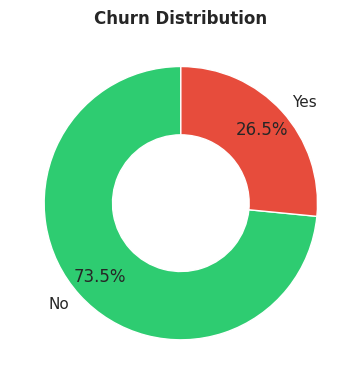

In [30]:
fig, axes = plt.subplots(figsize=(4, 4))

# Donut chart
wedge_colors = ['#2ECC71', '#E74C3C']
wedges, texts, autotexts = axes.pie(
    churn_counts, labels=churn_counts.index,
    autopct='%1.1f%%', colors=wedge_colors,
    pctdistance=0.80, wedgeprops=dict(width=0.5),
    startangle=90
)
axes.set_title('Churn Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Contract, Tenure & Payment Analysis

In [13]:
# Churn rate by contract
contract_churn = (df.groupby('Contract')['Churned']
                    .agg(['mean', 'count', 'sum'])
                    .rename(columns={'mean':'Churn Rate','count':'Customers','sum':'Churned'})
                    .reset_index())
contract_churn['Churn Rate %'] = (contract_churn['Churn Rate'] * 100).round(1)
contract_churn.sort_values('Churn Rate %', ascending=False)

,Contract,Churn Rate,Customers,Churned,Churn Rate %
0,Month-to-month,0.427097,3875,1655,42.7
1,One year,0.112695,1473,166,11.3
2,Two year,0.028319,1695,48,2.8


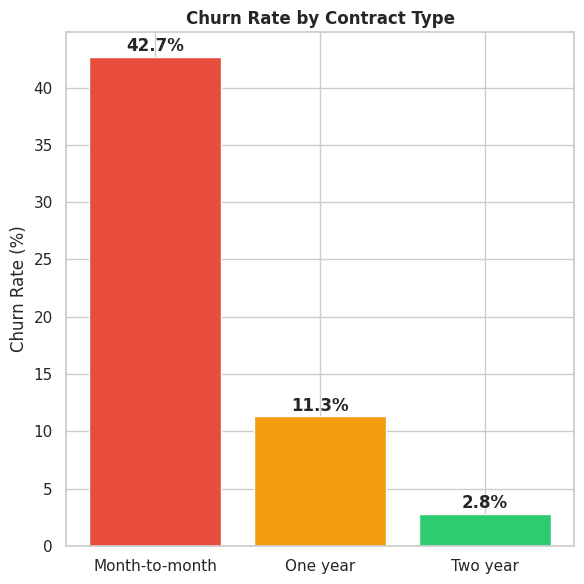

In [32]:
fig, axes = plt.subplots(figsize=(6, 6))

# Churn rate by contract type
bars = axes.bar(contract_churn['Contract'], contract_churn['Churn Rate %'],
                   color=['#E74C3C','#F39C12','#2ECC71'])
axes.set_title('Churn Rate by Contract Type', fontweight='bold')
axes.set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, contract_churn['Churn Rate %']):
    axes.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

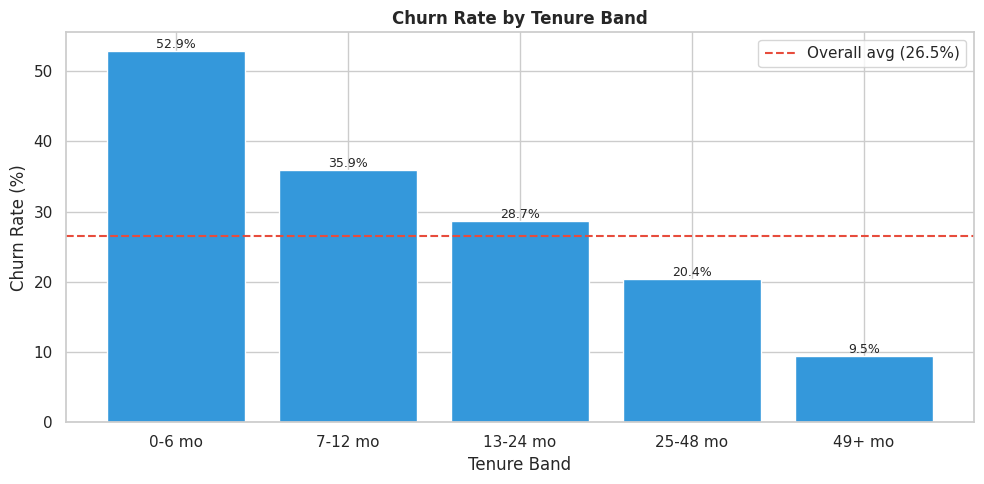

In [15]:
# Churn rate by tenure band
tenure_churn = (df.groupby('Tenure Band', observed=True)['Churned']
                  .agg(Customers='count', Churned='sum', Churn_Rate='mean')
                  .reset_index())
tenure_churn['Churn Rate %'] = (tenure_churn['Churn_Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tenure_churn['Tenure Band'].astype(str),
              tenure_churn['Churn Rate %'],
              color='#3498DB', edgecolor='white')
avg = df['Churned'].mean() * 100
ax.axhline(avg, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({avg:.1f}%)')
ax.set_title('Churn Rate by Tenure Band', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Band')
for bar, val in zip(bars, tenure_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4, f'{val}%', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

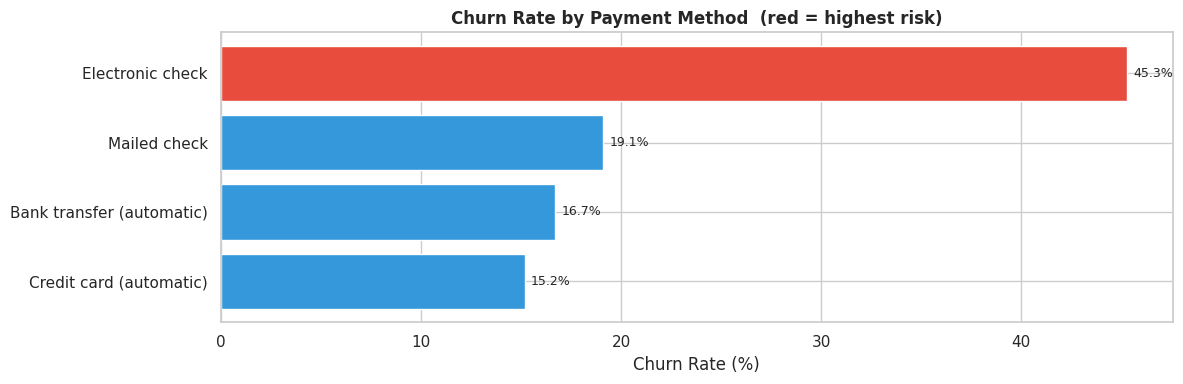

In [21]:
# Churn rate by payment method
pay_churn = (df.groupby('PaymentMethod')['Churned']
               .agg(Customers='count', Churned='sum', Churn_Rate='mean')
               .reset_index()
               .sort_values('Churn_Rate', ascending=True))
pay_churn['Churn Rate %'] = (pay_churn['Churn_Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#E74C3C' if v == pay_churn['Churn Rate %'].max() else '#3498DB'
          for v in pay_churn['Churn Rate %']]
ax.barh(pay_churn['PaymentMethod'], pay_churn['Churn Rate %'], color=colors)
ax.set_title('Churn Rate by Payment Method  (red = highest risk)', fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for i, val in enumerate(pay_churn['Churn Rate %']):
    ax.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Service Usage Analysis

In [17]:
# Churn rate by internet service
inet_churn = (df.groupby('InternetService')['Churned']
                .agg(Customers='count', Churn_Rate='mean')
                .reset_index())
inet_churn['Churn Rate %'] = (inet_churn['Churn_Rate'] * 100).round(1)
inet_churn

,InternetService,Customers,Churn_Rate,Churn Rate %
0,DSL,2421,0.189591,19.0
1,Fiber optic,3096,0.418928,41.9
2,No,1526,0.074050,7.4


## 6. Demographics Analysis

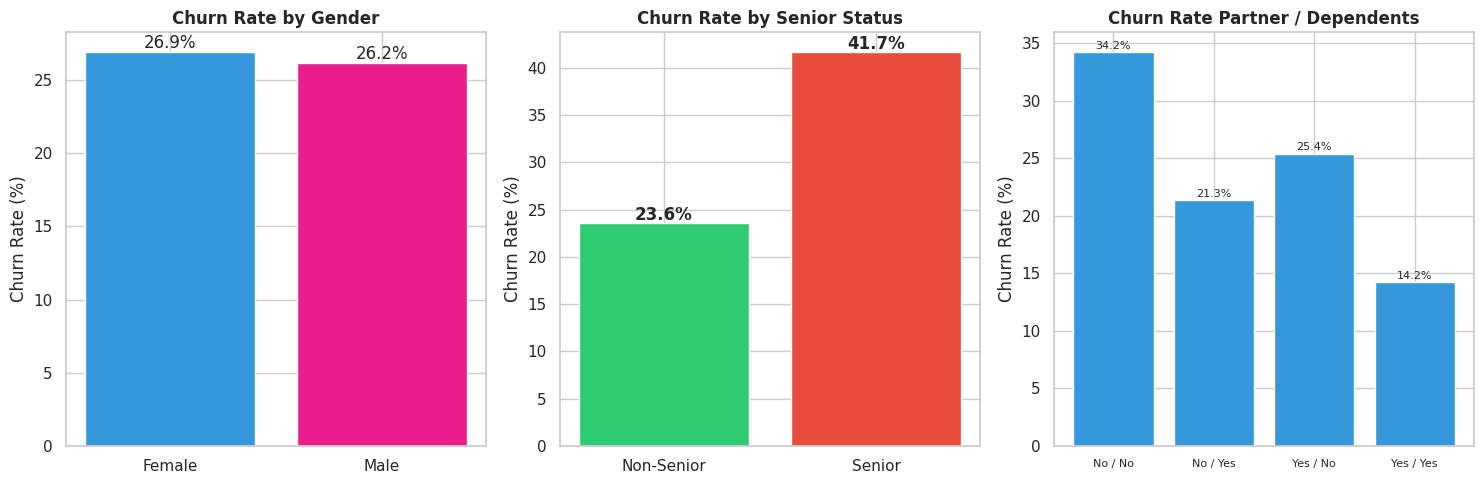

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gender
gender_churn = df.groupby('gender')['Churned'].mean() * 100
axes[0].bar(gender_churn.index, gender_churn.values,
            color=['#3498DB','#E91E8C'])
axes[0].set_title('Churn Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center')

# Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churned'].mean() * 100
axes[1].bar(['Non-Senior', 'Senior'], senior_churn.values,
            color=['#2ECC71', '#E74C3C'])
axes[1].set_title('Churn Rate by Senior Status', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(senior_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Partner & Dependents
combo = df.groupby(['Partner','Dependents'])['Churned'].mean() * 100
combo = combo.reset_index()
combo['Label'] = combo['Partner'] + ' / ' + combo['Dependents']
axes[2].bar(combo['Label'], combo['Churned'], color='#3498DB')
axes[2].set_title('Churn Rate Partner / Dependents', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', labelsize=8)
for i, v in enumerate(combo['Churned']):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Revenue at Risk

In [26]:
total_mrr   = df['MonthlyCharges'].sum()
churned_mrr = df.loc[df['Churned'] == 1, 'MonthlyCharges'].sum()
retained_mrr= df.loc[df['Churned'] == 0, 'MonthlyCharges'].sum()

print(f"Total Monthly Revenue  : ${total_mrr:,.2f}")
print(f"Revenue Lost (churned) : ${churned_mrr:,.2f}  ({churned_mrr/total_mrr*100:.1f}%)")
print(f"Revenue Retained       : ${retained_mrr:,.2f}  ({retained_mrr/total_mrr*100:.1f}%)")

Total Monthly Revenue  : $456,116.60
Revenue Lost (churned) : $139,130.85  (30.5%)
Revenue Retained       : $316,985.75  (69.5%)


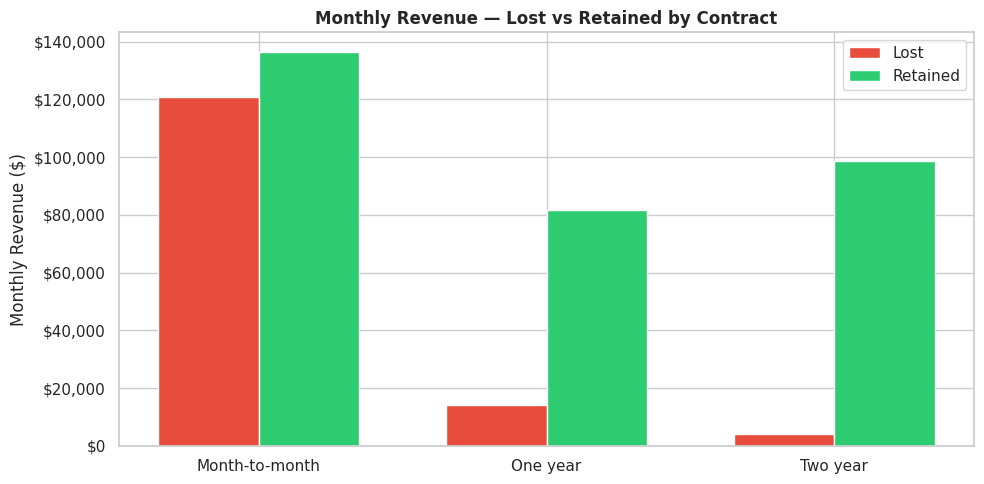

In [27]:
# Revenue lost vs retained by contract type
rev_risk = df.groupby('Contract').apply(
    lambda x: pd.Series({
        'Lost ($)':     x.loc[x['Churned']==1, 'MonthlyCharges'].sum(),
        'Retained ($)': x.loc[x['Churned']==0, 'MonthlyCharges'].sum(),
    })
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rev_risk))
w = 0.35
ax.bar(x - w/2, rev_risk['Lost ($)'],     w, label='Lost',     color='#E74C3C')
ax.bar(x + w/2, rev_risk['Retained ($)'], w, label='Retained', color='#2ECC71')
ax.set_xticks(x)
ax.set_xticklabels(rev_risk['Contract'])
ax.set_title('Monthly Revenue — Lost vs Retained by Contract', fontweight='bold')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Key Takeaways

| # | Finding |
|---|---------|
| 1 | **Overall churn rate is 26.5%** — roughly 1 in 4 customers churns |
| 2 | **Month-to-month contracts** have a 42.7% churn rate vs just 2.8% for two-year contracts |
| 3 | **First 6 months are critical** — 52.9% churn rate; drops sharply as tenure increases |
| 4 | **Electronic check users churn at 45%** — 3× higher than automatic payment methods |
| 5 | **Fiber optic customers churn most** (41.9%) despite paying higher monthly charges |
| 6 | **Add-on services reduce churn** — customers with OnlineSecurity or TechSupport churn significantly less |
| 7 | **More services = lower churn** — customers with 5-6 services have the lowest churn rate |
| 8 | **Senior citizens churn at 41.7%** vs 23.6% for non-seniors — a key at-risk group |
| 9 | **$139K in monthly revenue** is already lost to churn (30.5% of total MRR) |
